# Flight Delay Model Analysis

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from main import main

results, X_test, y_test, FEATURE_COLS = main()

COVID cutoff: 2020-03-01  (only data before this date is used)

Loaded 171,666 rows x 21 columns from /Users/daniloruberti/.cache/kagglehub/datasets/sriharshaeedala/airline-delay/versions/1/Airline_Delay_Cause.csv
  [filter_pre_covid] Before: 171,426 rows  |  date range 2013-08-01 → 2023-08-01
  Row counts by year (pre-filter):
year
2013     6724
2014    13958
2015    13516
2016    12198
2017    12508
2018    20196
2019    20932
2020    18769
2021    19932
2022    20338
2023    12355
  [filter_pre_covid] After : 103,593 rows  |  date range 2013-08-01 → 2020-02-01
  Row counts by year (post-filter):
year
2013     6724
2014    13958
2015    13516
2016    12198
2017    12508
2018    20196
2019    20932
2020     3561
New features added:
['lag1_delay', 'lag2_delay', 'lag3_delay', 'rolling_arrivals_3', 'rolling_late_aircraft_3', 'rolling_cancel_rate_3', 'traffic_weather_interaction', 'traffic_peak_interaction']
Shape before dropna: (103593, 40)
Shape after dropna: (87378, 40)
  Train: 2014–2

## 3. Predicted vs Actual

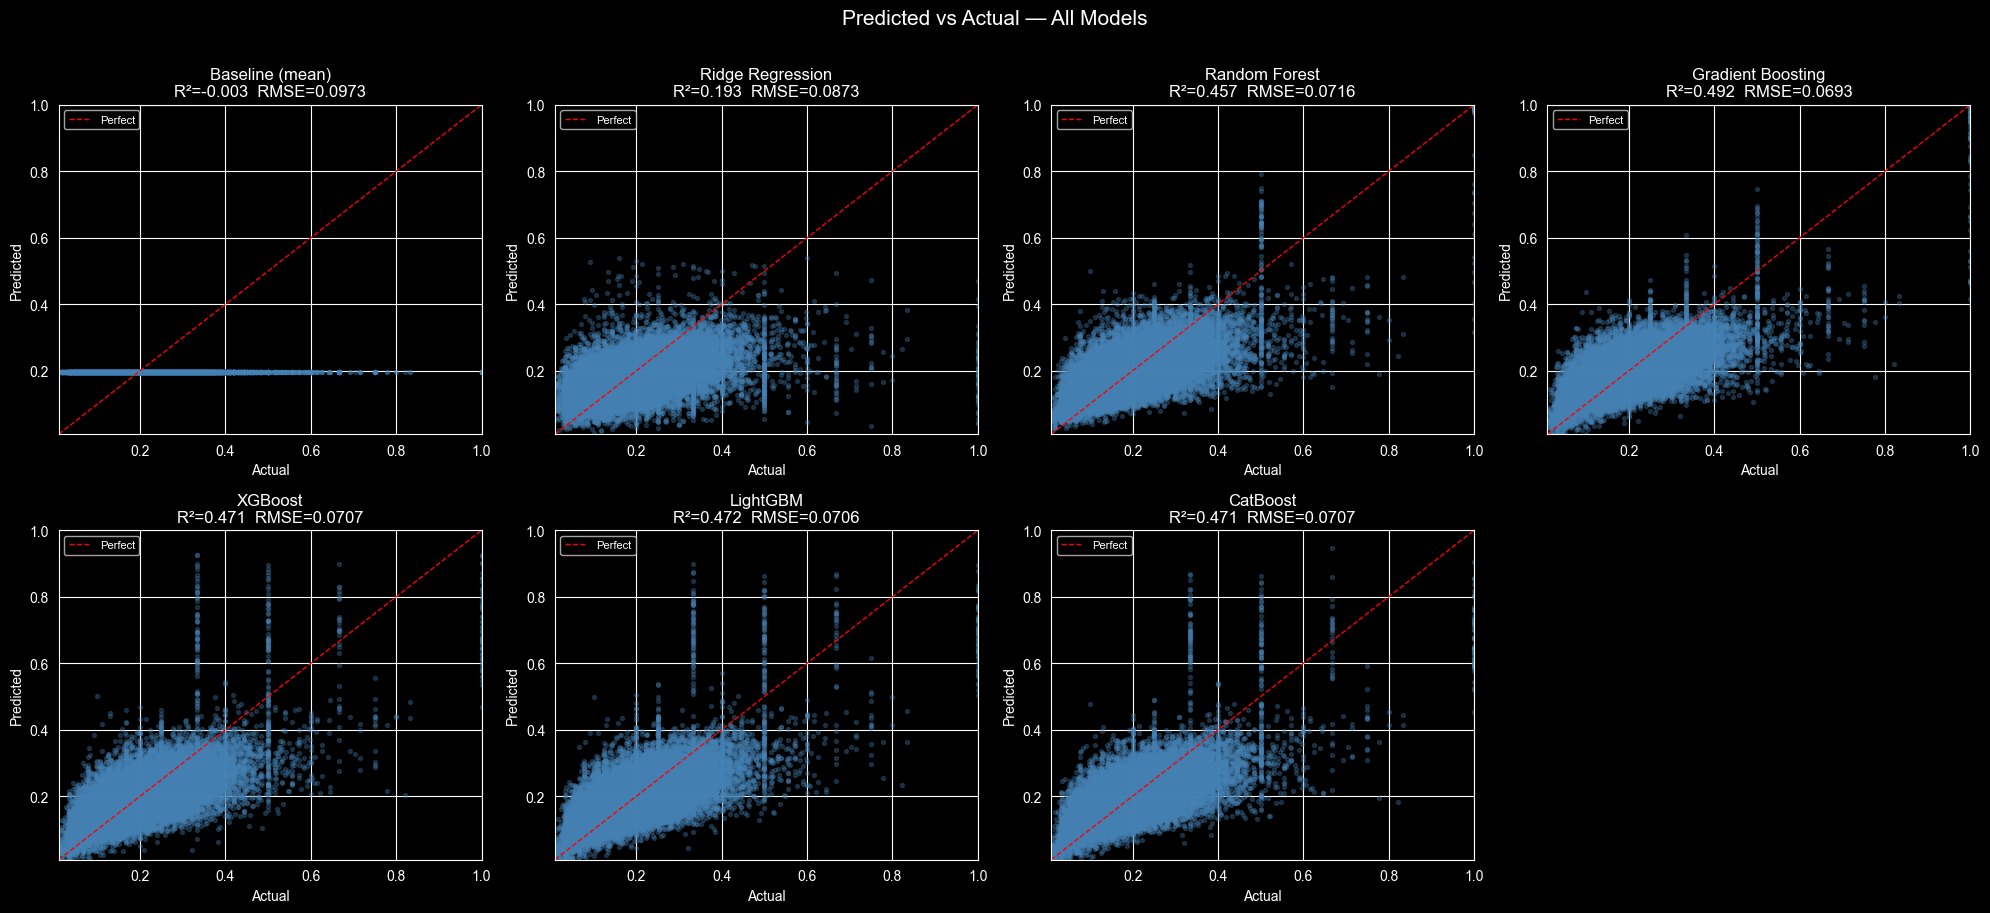

In [2]:
n = len(results)
ncols = 4
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = axes.flatten()

lims = [float(y_test.min()), float(y_test.max())]

for ax, r in zip(axes, results):
    preds = np.clip(r['fitted'].predict(X_test), 0, 1)
    ax.scatter(y_test, preds, alpha=0.3, s=8, color='steelblue')
    ax.plot(lims, lims, 'r--', lw=1, label='Perfect')
    ax.set_title(f"{r['model']}\nR²={r['R2']:.3f}  RMSE={r['RMSE']:.4f}")
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.legend(fontsize=8)

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('Predicted vs Actual — All Models', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 4. Residual Errors

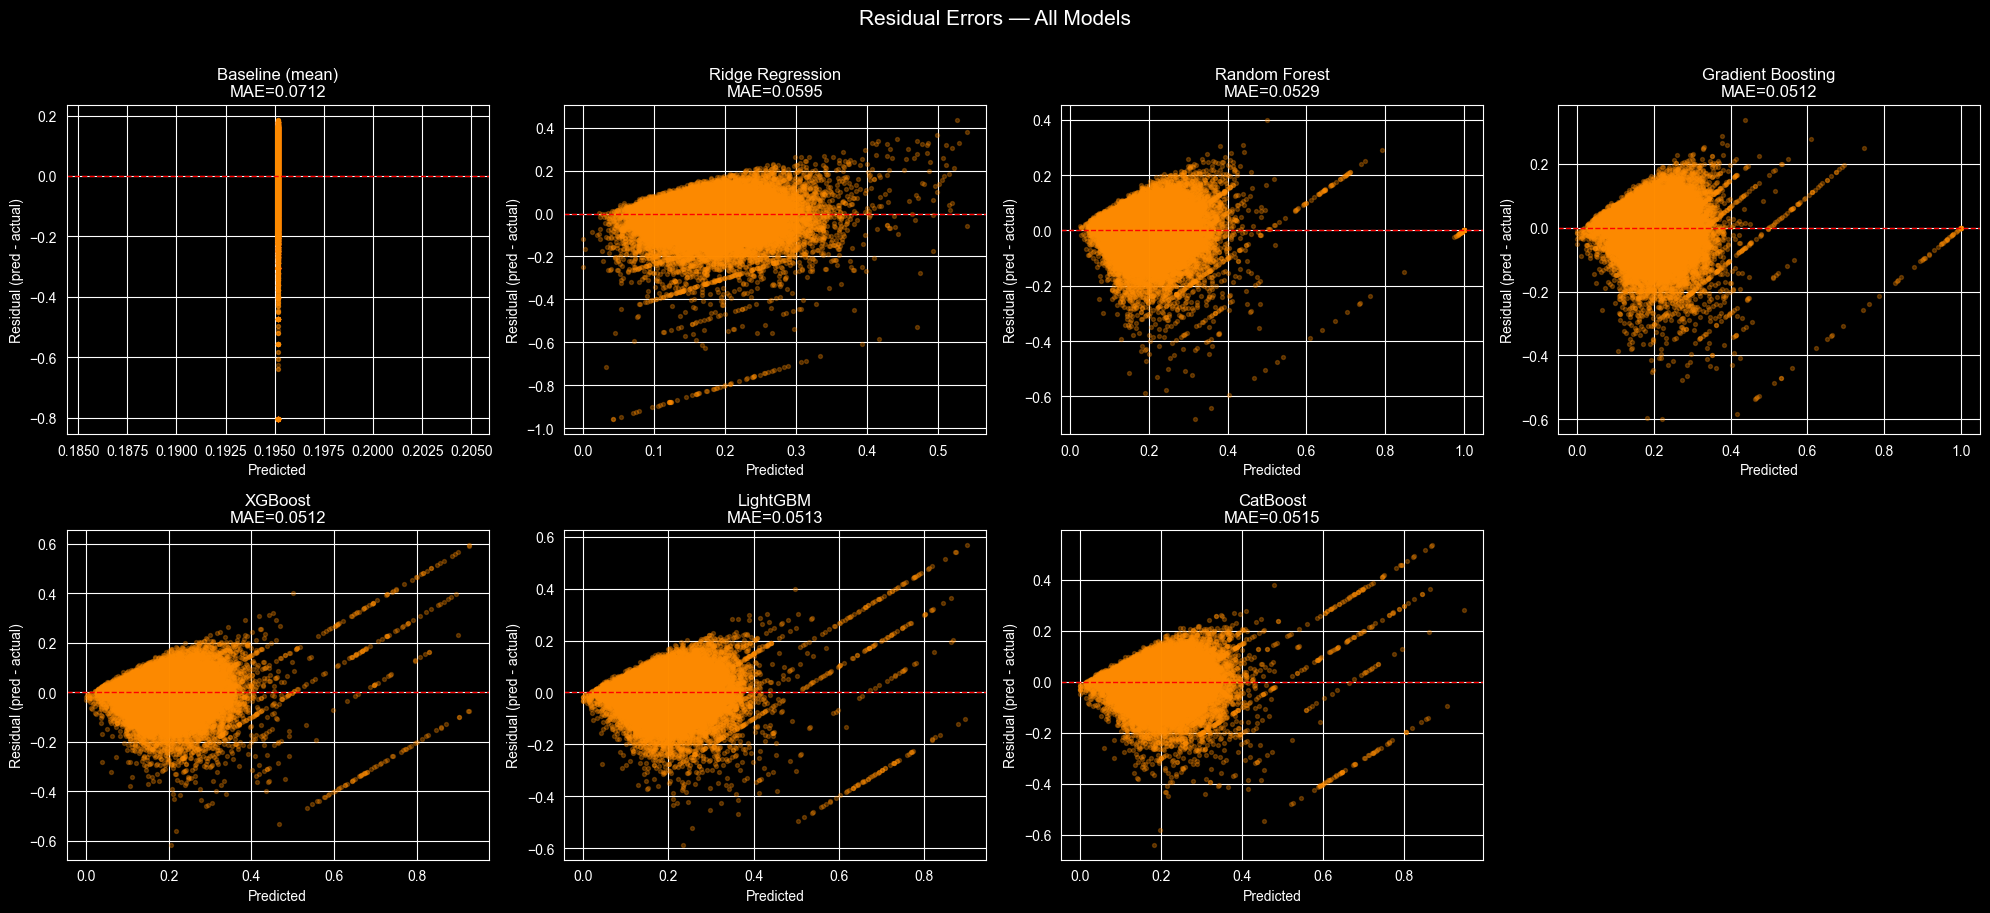

In [3]:
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = axes.flatten()

for ax, r in zip(axes, results):
    preds = np.clip(r['fitted'].predict(X_test), 0, 1)
    residuals = preds - np.array(y_test)
    ax.scatter(preds, residuals, alpha=0.3, s=8, color='darkorange')
    ax.axhline(0, color='red', lw=1, ls='--')
    ax.set_title(f"{r['model']}\nMAE={r['MAE']:.4f}")
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Residual (pred - actual)')

for ax in axes[n:]:
    ax.set_visible(False)

fig.suptitle('Residual Errors — All Models', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

## 5. Feature Importance Consistency

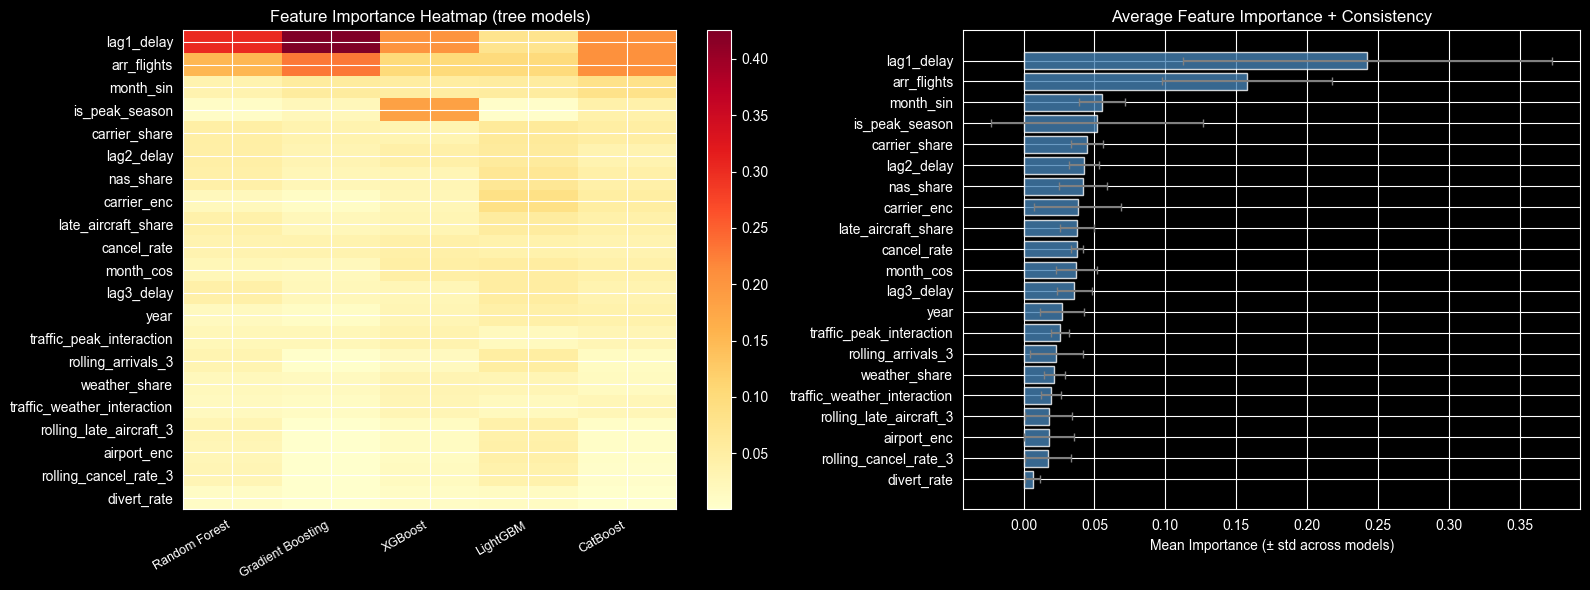

,Random Forest,Gradient Boosting,XGBoost,LightGBM,CatBoost,mean
lag1_delay,0.3030,0.4253,0.2027,0.0756,0.2067,0.2427
arr_flights,0.1513,0.2301,0.1011,0.0989,0.2068,0.1577
month_sin,0.0353,0.0554,0.0521,0.0542,0.0808,0.0556
is_peak_season,0.0080,0.0224,0.1830,0.0048,0.0412,0.0519
carrier_share,0.0471,0.0359,0.0322,0.0603,0.0489,0.0449
lag2_delay,0.0464,0.0302,0.0440,0.0580,0.0346,0.0426
nas_share,0.0450,0.0264,0.0268,0.0678,0.0446,0.0421
carrier_enc,0.0198,0.0093,0.0252,0.0862,0.0507,0.0382
late_aircraft_share,0.0417,0.0231,0.0287,0.0543,0.0400,0.0376
cancel_rate,0.0336,0.0356,0.0439,0.0399,0.0346,0.0375


In [4]:
tree_results = [r for r in results if hasattr(r['fitted'], 'feature_importances_')]

imp_df = pd.DataFrame(
    {r['model']: r['fitted'].feature_importances_ for r in tree_results},
    index=FEATURE_COLS
)
imp_df = imp_df.div(imp_df.sum(axis=0), axis=1)
imp_df['mean'] = imp_df.mean(axis=1)
imp_df = imp_df.sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
ax = axes[0]
heat_data = imp_df.drop(columns='mean').values
im = ax.imshow(heat_data, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(tree_results)))
ax.set_xticklabels([r['model'] for r in tree_results], rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_yticklabels(imp_df.index)
ax.set_title('Feature Importance Heatmap (tree models)')
plt.colorbar(im, ax=ax)

# Mean + std bar chart
ax = axes[1]
mean_imp = imp_df['mean']
std_imp  = imp_df.drop(columns='mean').std(axis=1)
ax.barh(mean_imp.index[::-1], mean_imp.values[::-1],
        xerr=std_imp.values[::-1], color='steelblue', alpha=0.8,
        error_kw=dict(ecolor='gray', capsize=3))
ax.set_xlabel('Mean Importance (± std across models)')
ax.set_title('Average Feature Importance + Consistency')

plt.tight_layout()
plt.show()

display(imp_df.round(4))